# Eksperymenty hiperparametrów

Notebook sprawdza, jak wybrane hiperparametry wpływają na accuracy modeli LSTM i Transformer

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from scripts import (
    DataFixedParams,
    DataGridParams,
    Experiment,
    FeatureFixedParams,
    FitFixedParams,
    FitGridParams,
    LABEL_ORDER,
    ModelGridParams,
    experiment_grid_dataframe,
    prepare_experiment_datasets,
    train_experiment,
)

LABEL_ORDER

('yes',
 'no',
 'up',
 'down',
 'left',
 'right',
 'on',
 'off',
 'stop',
 'go',
 'unknown',
 'silence')

## Konfiguracja bazowa

In [11]:
EPOCHS = 10
OUTPUT_DIR = "reports/03_hyperparameter_experiments"
ARCHITECTURES = ["lstm", "transformer"]
# ARCHITECTURES = ["transformer"]

DATA_GRID_CONFIG = {
    "train_fraction": 0.2,
    "validation_fraction": 1,
    "test_fraction": 1,
    "unknown_fraction": 1,
    "silence_samples": 1000,
    "sampling_strategy": "natural",
    "seed": 42,
}

FEATURE_CONFIG = {
    "n_mels": 64,
    "n_fft": 512,
    "hop_length": 160,
    "normalize": True,
}

FIT_FIXED_CONFIG = {
    "device": "cuda",
    "use_tqdm": True,
    "progress_backend": "terminal",
    "verbose": True,
    "early_stopping": True,
}

BASE_HYPERPARAMETERS = {
    "dropout": 0.2,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "batch_size": 128,
    "capacity": 64,
}

base_data_fixed = DataFixedParams(
    cache_dir=".cache/hyperparameter_audio",
    reuse_cached_dataset=False,
    output_dir=OUTPUT_DIR,
)
base_data_grid = DataGridParams(**DATA_GRID_CONFIG)
base_feature_fixed = FeatureFixedParams(**FEATURE_CONFIG)
base_fit_fixed = FitFixedParams(**FIT_FIXED_CONFIG)

pd.DataFrame(
    [
        {"group": "data", **DATA_GRID_CONFIG},
        {"group": "features", **FEATURE_CONFIG},
        {"group": "fit", **FIT_FIXED_CONFIG, "epochs": EPOCHS},
        {"group": "baseline", **BASE_HYPERPARAMETERS},
    ]
)

,group,train_fraction,validation_fraction,test_fraction,unknown_fraction,silence_samples,sampling_strategy,seed,n_mels,n_fft,...,use_tqdm,progress_backend,verbose,early_stopping,epochs,dropout,learning_rate,weight_decay,batch_size,capacity
0,data,0.2,1.0,1.0,1.0,1000.0,natural,42.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,features,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.0,512.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,fit,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,terminal,True,True,10.0,NaN,NaN,NaN,NaN,NaN
3,baseline,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.2,0.001,0.0001,128.0,64.0


## Konfiguracje eksperymentów

Poniższa tabela jest głównym miejscem edycji. Każde badanie zmienia jeden parametr względem `BASE_HYPERPARAMETERS`; pozostałe ustawienia zostają stałe.

In [12]:
STUDIES = [
    {"study": "architecture", "parameter": "model_type", "values": ["lstm", "transformer"]},
    {"study": "dropout", "parameter": "dropout", "values": [0.0, 0.1, 0.2, 0.4, 0.5]},
    {"study": "learning_rate", "parameter": "learning_rate", "values": [1e-4, 5e-4, 1e-3, 5e-3]},
    {"study": "weight_decay", "parameter": "weight_decay", "values": [0.0, 1e-5, 1e-4, 1e-3]},
    {"study": "batch_size", "parameter": "batch_size", "values": [32, 64, 128, 256]},
    {"study": "capacity", "parameter": "model_capacity", "values": [16, 32, 64, 128]},
]

pd.DataFrame(STUDIES)

,study,parameter,values
0,architecture,model_type,"[lstm, transformer]"
1,dropout,dropout,"[0.0, 0.1, 0.2, 0.4, 0.5]"
2,learning_rate,learning_rate,"[0.0001, 0.0005, 0.001, 0.005]"
3,weight_decay,weight_decay,"[0.0, 1e-05, 0.0001, 0.001]"
4,batch_size,batch_size,"[32, 64, 128, 256]"
5,capacity,model_capacity,"[16, 32, 64, 128]"


In [13]:
def slug_value(value) -> str:
    return str(value).replace("-", "m").replace(".", "p")


def overrides_for(parameter: str, value) -> dict:
    if parameter == "model_type":
        return {}
    if parameter == "model_capacity":
        return {"capacity": value}
    return {parameter: value}


def make_experiment(name: str, architecture: str, overrides: dict | None = None) -> Experiment:
    hp = {**BASE_HYPERPARAMETERS, **(overrides or {})}

    return Experiment(
        name=name,
        data_fixed=base_data_fixed,
        data_grid=base_data_grid,
        feature_fixed=base_feature_fixed,
        model_grid=ModelGridParams(
            model_type=architecture,
            dropout=hp["dropout"],
            lstm_hidden_size=hp["capacity"],
            lstm_layers=2,
            lstm_bidirectional=True,
            transformer_d_model=hp["capacity"],
            transformer_heads=4,
            transformer_layers=2,
            transformer_ff_dim=hp["capacity"] * 2,
        ),
        fit_fixed=base_fit_fixed,
        fit_grid=FitGridParams(
            epochs=EPOCHS,
            batch_size=hp["batch_size"],
            learning_rate=hp["learning_rate"],
            weight_decay=hp["weight_decay"],
        ),
    )


experiments = {}
plan_rows = []

for spec in STUDIES:
    parameter = spec["parameter"]
    for value in spec["values"]:
        architectures = [value] if parameter == "model_type" else ARCHITECTURES
        for architecture in architectures:
            overrides = overrides_for(parameter, value)
            hp = {**BASE_HYPERPARAMETERS, **overrides}
            experiment_name = f"03_{spec['study']}_{architecture}_{parameter}_{slug_value(value)}"

            experiments[experiment_name] = make_experiment(experiment_name, architecture, overrides)
            plan_rows.append(
                {
                    "study": spec["study"],
                    "parameter": parameter,
                    "value": value,
                    "architecture": architecture,
                    **hp,
                    "experiment_name": experiment_name,
                    "runs": 1,
                }
            )

experiment_plan = pd.DataFrame(plan_rows)
plan_columns = [
    "study",
    "parameter",
    "value",
    "architecture",
    "dropout",
    "learning_rate",
    "weight_decay",
    "batch_size",
    "capacity",
    "experiment_name",
    "runs",
]

experiment_plan[plan_columns]

,study,parameter,value,architecture,dropout,learning_rate,weight_decay,batch_size,capacity,experiment_name,runs
0,architecture,model_type,lstm,lstm,0.2,0.0010,0.00010,128,64,03_architecture_lstm_model_type_lstm,1
1,architecture,model_type,transformer,transformer,0.2,0.0010,0.00010,128,64,03_architecture_transformer_model_type_transfo...,1
2,dropout,dropout,0.0,lstm,0.0,0.0010,0.00010,128,64,03_dropout_lstm_dropout_0p0,1
3,dropout,dropout,0.0,transformer,0.0,0.0010,0.00010,128,64,03_dropout_transformer_dropout_0p0,1
4,dropout,dropout,0.1,lstm,0.1,0.0010,0.00010,128,64,03_dropout_lstm_dropout_0p1,1
5,dropout,dropout,0.1,transformer,0.1,0.0010,0.00010,128,64,03_dropout_transformer_dropout_0p1,1
6,dropout,dropout,0.2,lstm,0.2,0.0010,0.00010,128,64,03_dropout_lstm_dropout_0p2,1
7,dropout,dropout,0.2,transformer,0.2,0.0010,0.00010,128,64,03_dropout_transformer_dropout_0p2,1
8,dropout,dropout,0.4,lstm,0.4,0.0010,0.00010,128,64,03_dropout_lstm_dropout_0p4,1
9,dropout,dropout,0.4,transformer,0.4,0.0010,0.00010,128,64,03_dropout_transformer_dropout_0p4,1


In [14]:
experiment_plan.groupby("study", as_index=False)["runs"].sum()

,study,runs
0,architecture,2
1,batch_size,8
2,capacity,8
3,dropout,10
4,learning_rate,8
5,weight_decay,8


## Wybór konfiguracji

Domyślnie zaznaczone są wszystkie badania. Jeśli chcesz uruchomić tylko część, usuń wybrane nazwy z `selected_studies` przed wykonaniem komórek treningowych.

In [15]:
selected_studies = [
    "architecture",
    "dropout",
    "learning_rate",
    "weight_decay",
    "batch_size",
    "capacity",
]

selected_plan = experiment_plan[experiment_plan["study"].isin(selected_studies)].reset_index(drop=True)
selected_plan[plan_columns]

,study,parameter,value,architecture,dropout,learning_rate,weight_decay,batch_size,capacity,experiment_name,runs
0,architecture,model_type,lstm,lstm,0.2,0.0010,0.00010,128,64,03_architecture_lstm_model_type_lstm,1
1,architecture,model_type,transformer,transformer,0.2,0.0010,0.00010,128,64,03_architecture_transformer_model_type_transfo...,1
2,dropout,dropout,0.0,lstm,0.0,0.0010,0.00010,128,64,03_dropout_lstm_dropout_0p0,1
3,dropout,dropout,0.0,transformer,0.0,0.0010,0.00010,128,64,03_dropout_transformer_dropout_0p0,1
4,dropout,dropout,0.1,lstm,0.1,0.0010,0.00010,128,64,03_dropout_lstm_dropout_0p1,1
5,dropout,dropout,0.1,transformer,0.1,0.0010,0.00010,128,64,03_dropout_transformer_dropout_0p1,1
6,dropout,dropout,0.2,lstm,0.2,0.0010,0.00010,128,64,03_dropout_lstm_dropout_0p2,1
7,dropout,dropout,0.2,transformer,0.2,0.0010,0.00010,128,64,03_dropout_transformer_dropout_0p2,1
8,dropout,dropout,0.4,lstm,0.4,0.0010,0.00010,128,64,03_dropout_lstm_dropout_0p4,1
9,dropout,dropout,0.4,transformer,0.4,0.0010,0.00010,128,64,03_dropout_transformer_dropout_0p4,1


In [16]:
# Pełna konfiguracja pierwszego zaplanowanego eksperymentu.
example_experiment = experiments[selected_plan.loc[0, "experiment_name"]]
experiment_grid_dataframe(example_experiment)

,experiment,data.train_fraction,data.validation_fraction,data.test_fraction,data.unknown_fraction,data.silence_samples,data.sampling_strategy,data.seed,model.model_type,model.dropout,...,model.lstm_layers,model.lstm_bidirectional,model.transformer_d_model,model.transformer_heads,model.transformer_layers,model.transformer_ff_dim,fit.epochs,fit.batch_size,fit.learning_rate,fit.weight_decay
0,03_architecture_lstm_model_type_lstm,0.2,1,1,1,1000,natural,42,lstm,0.2,...,2,True,64,4,2,128,10,128,0.001,0.0001


## Przygotowanie danych

In [17]:
data_cache_experiment = make_experiment(
    "03_shared_hyperparameter_data_cache",
    architecture="lstm",
)

prepared_data = prepare_experiment_datasets(data_cache_experiment)


Building dataset


Extracting archive: 100%|██████████| 1/1 [00:47<00:00, 47.66s/it]


  -> samples | train=10379 | validation=6903 | test=6941
     class        train  validation  test
     down          369         264   253
     go            373         260   251
     left          368         247   267
     no            371         270   252
     off           368         256   262
     on            373         257   246
     right         371         256   259
     silence       158         105   106
     stop          377         246   249
     unknown      6510        4221  4268
     up            369         260   272
     yes           372         261   256


## Uruchomienie eksperymentów

In [18]:
all_results = []

for index, row in selected_plan.iterrows():
    experiment_name = row["experiment_name"]
    experiment = experiments[experiment_name]
    print(f"[{index + 1}/{len(selected_plan)}] {experiment_name}")

    summary = train_experiment(experiment, prepared_data).copy()
    summary.insert(0, "study", row["study"])
    summary.insert(1, "parameter", row["parameter"])
    summary.insert(2, "value", row["value"])
    summary.insert(3, "architecture", row["architecture"])
    summary.insert(4, "experiment_name", experiment_name)
    all_results.append(summary)

all_results = pd.concat(all_results, ignore_index=True)
output_path = Path(OUTPUT_DIR) / "hyperparameter_experiment_summary.csv"
output_path.parent.mkdir(parents=True, exist_ok=True)
all_results.to_csv(output_path, index=False)
all_results.sort_values("test_accuracy", ascending=False)

[1/44] 03_architecture_lstm_model_type_lstm
Starting experiment: 03_architecture_lstm_model_type_lstm

Configuration run 1/1:
DATA (variable):
  - train_fraction: 0.2
  - validation_fraction: 1
  - test_fraction: 1
  - unknown_fraction: 1
  - silence_samples: 1000
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: lstm
  - dropout: 0.2
  - lstm_hidden_size: 64
  - lstm_layers: 2
  - lstm_bidirectional: True
  - transformer_d_model: 64
  - transformer_heads: 4
  - transformer_layers: 2
  - transformer_ff_dim: 128
FIT (variable):
  - epochs: 10
  - batch_size: 128
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cuda


Training: 100%|██████████| 10/10 [02:26<00:00, 14.66s/it, loss=0.3322, lr=0.001, val_acc=0.8814, val_loss=0.4043]


Training finished in 151.73 seconds



Experiment finished | total runs = 1
Experiment cache already empty.
[2/44] 03_architecture_transformer_model_type_transformer
Starting experiment: 03_architecture_transformer_model_type_transformer

Configuration run 1/1:
DATA (variable):
  - train_fraction: 0.2
  - validation_fraction: 1
  - test_fraction: 1
  - unknown_fraction: 1
  - silence_samples: 1000
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: transformer
  - dropout: 0.2
  - lstm_hidden_size: 64
  - lstm_layers: 2
  - lstm_bidirectional: True
  - transformer_d_model: 64
  - transformer_heads: 4
  - transformer_layers: 2
  - transformer_ff_dim: 128
FIT (variable):
  - epochs: 10
  - batch_size: 128
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cuda


Training: 100%|██████████| 10/10 [02:33<00:00, 15.34s/it, loss=0.3217, lr=0.001, val_acc=0.8732, val_loss=0.4049]


Training finished in 158.70 seconds



Experiment finished | total runs = 1
Experiment cache already empty.
[3/44] 03_dropout_lstm_dropout_0p0
Starting experiment: 03_dropout_lstm_dropout_0p0

Configuration run 1/1:
DATA (variable):
  - train_fraction: 0.2
  - validation_fraction: 1
  - test_fraction: 1
  - unknown_fraction: 1
  - silence_samples: 1000
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: lstm
  - dropout: 0.0
  - lstm_hidden_size: 64
  - lstm_layers: 2
  - lstm_bidirectional: True
  - transformer_d_model: 64
  - transformer_heads: 4
  - transformer_layers: 2
  - transformer_ff_dim: 128
FIT (variable):
  - epochs: 10
  - batch_size: 128
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cuda


...

Training: 100%|██████████| 10/10 [02:43<00:00, 16.35s/it, loss=0.2363, lr=0.001, val_acc=0.9003, val_loss=0.3294]


Training finished in 170.33 seconds



Experiment finished | total runs = 1
Experiment cache already empty.
[44/44] 03_capacity_transformer_model_capacity_128
Starting experiment: 03_capacity_transformer_model_capacity_128

Configuration run 1/1:
DATA (variable):
  - train_fraction: 0.2
  - validation_fraction: 1
  - test_fraction: 1
  - unknown_fraction: 1
  - silence_samples: 1000
  - sampling_strategy: natural
  - seed: 42
MODEL (variable):
  - model_type: transformer
  - dropout: 0.2
  - lstm_hidden_size: 128
  - lstm_layers: 2
  - lstm_bidirectional: True
  - transformer_d_model: 128
  - transformer_heads: 4
  - transformer_layers: 2
  - transformer_ff_dim: 256
FIT (variable):
  - epochs: 10
  - batch_size: 128
  - learning_rate: 0.001
  - weight_decay: 0.0001

Training model
Using device: cuda


Training: 100%|██████████| 10/10 [02:37<00:00, 15.71s/it, loss=0.2254, lr=0.001, val_acc=0.8841, val_loss=0.3781]


Training finished in 164.00 seconds



Experiment finished | total runs = 1
Experiment cache already empty.


,study,parameter,value,architecture,experiment_name,run,best_epoch,epochs_trained,stopped_early,train_loss,train_accuracy,validation_loss,validation_accuracy,test_loss,test_accuracy
28,batch_size,batch_size,32,lstm,03_batch_size_lstm_batch_size_32,lstm_train0_2_val1_test1_lr0_001_seed42,8,10,False,0.300645,0.905675,0.350298,0.892945,0.352976,0.899006
42,capacity,model_capacity,128,lstm,03_capacity_lstm_model_capacity_128,lstm_train0_2_val1_test1_lr0_001_seed42,10,10,False,0.236341,0.924174,0.329400,0.900333,0.353727,0.894684
3,dropout,dropout,0.0,transformer,03_dropout_transformer_dropout_0p0,trfm_train0_2_val1_test1_lr0_001_seed42,10,10,False,0.221017,0.929955,0.352176,0.891786,0.372146,0.892667
30,batch_size,batch_size,64,lstm,03_batch_size_lstm_batch_size_64,lstm_train0_2_val1_test1_lr0_001_seed42,10,10,False,0.280979,0.911359,0.337743,0.896856,0.357268,0.891658
29,batch_size,batch_size,32,transformer,03_batch_size_transformer_batch_size_32,trfm_train0_2_val1_test1_lr0_001_seed42,9,10,False,0.233689,0.925426,0.352467,0.896856,0.385518,0.890794
18,learning_rate,learning_rate,0.005,lstm,03_learning_rate_lstm_learning_rate_0p005,lstm_train0_2_val1_test1_lr0_005_seed42,9,10,False,0.316162,0.896522,0.355994,0.889758,0.370987,0.889209
43,capacity,model_capacity,128,transformer,03_capacity_transformer_model_capacity_128,trfm_train0_2_val1_test1_lr0_001_seed42,10,10,False,0.225382,0.928895,0.378132,0.884108,0.411332,0.886904
31,batch_size,batch_size,64,transformer,03_batch_size_transformer_batch_size_64,trfm_train0_2_val1_test1_lr0_001_seed42,9,10,False,0.294653,0.908180,0.384409,0.884688,0.417998,0.879556
4,dropout,dropout,0.1,lstm,03_dropout_lstm_dropout_0p1,lstm_train0_2_val1_test1_lr0_001_seed42,9,10,False,0.362985,0.885442,0.396738,0.872954,0.405217,0.879412
2,dropout,dropout,0.0,lstm,03_dropout_lstm_dropout_0p0,lstm_train0_2_val1_test1_lr0_001_seed42,9,10,False,0.340448,0.892186,0.390999,0.880921,0.407430,0.878260


## Wczytanie zapisanych wyników

Jeśli notebook został przerwany po treningu, ta komórka pozwala wrócić do analizy bez ponownego uruchamiania modeli.

In [19]:
summary_path = Path(OUTPUT_DIR) / "hyperparameter_experiment_summary.csv"

if summary_path.exists():
    all_results = pd.read_csv(summary_path)

all_results.sort_values("test_accuracy", ascending=False).head(10)

,study,parameter,value,architecture,experiment_name,run,best_epoch,epochs_trained,stopped_early,train_loss,train_accuracy,validation_loss,validation_accuracy,test_loss,test_accuracy
28,batch_size,batch_size,32,lstm,03_batch_size_lstm_batch_size_32,lstm_train0_2_val1_test1_lr0_001_seed42,8,10,False,0.300645,0.905675,0.350298,0.892945,0.352976,0.899006
42,capacity,model_capacity,128,lstm,03_capacity_lstm_model_capacity_128,lstm_train0_2_val1_test1_lr0_001_seed42,10,10,False,0.236341,0.924174,0.329400,0.900333,0.353727,0.894684
3,dropout,dropout,0.0,transformer,03_dropout_transformer_dropout_0p0,trfm_train0_2_val1_test1_lr0_001_seed42,10,10,False,0.221017,0.929955,0.352176,0.891786,0.372146,0.892667
30,batch_size,batch_size,64,lstm,03_batch_size_lstm_batch_size_64,lstm_train0_2_val1_test1_lr0_001_seed42,10,10,False,0.280979,0.911359,0.337743,0.896856,0.357268,0.891658
29,batch_size,batch_size,32,transformer,03_batch_size_transformer_batch_size_32,trfm_train0_2_val1_test1_lr0_001_seed42,9,10,False,0.233689,0.925426,0.352467,0.896856,0.385518,0.890794
18,learning_rate,learning_rate,0.005,lstm,03_learning_rate_lstm_learning_rate_0p005,lstm_train0_2_val1_test1_lr0_005_seed42,9,10,False,0.316162,0.896522,0.355994,0.889758,0.370987,0.889209
43,capacity,model_capacity,128,transformer,03_capacity_transformer_model_capacity_128,trfm_train0_2_val1_test1_lr0_001_seed42,10,10,False,0.225382,0.928895,0.378132,0.884108,0.411332,0.886904
31,batch_size,batch_size,64,transformer,03_batch_size_transformer_batch_size_64,trfm_train0_2_val1_test1_lr0_001_seed42,9,10,False,0.294653,0.908180,0.384409,0.884688,0.417998,0.879556
4,dropout,dropout,0.1,lstm,03_dropout_lstm_dropout_0p1,lstm_train0_2_val1_test1_lr0_001_seed42,9,10,False,0.362985,0.885442,0.396738,0.872954,0.405217,0.879412
2,dropout,dropout,0.0,lstm,03_dropout_lstm_dropout_0p0,lstm_train0_2_val1_test1_lr0_001_seed42,9,10,False,0.340448,0.892186,0.390999,0.880921,0.407430,0.878260


## Analiza wyników

In [20]:
best_by_study = (
    all_results.sort_values("test_accuracy", ascending=False)
    .groupby(["study", "architecture"], as_index=False)
    .first()
)

best_by_study[[
    "study",
    "architecture",
    "parameter",
    "value",
    "test_accuracy",
    "validation_accuracy",
    "best_epoch",
    "epochs_trained",
    "stopped_early",
]]

,study,architecture,parameter,value,test_accuracy,validation_accuracy,best_epoch,epochs_trained,stopped_early
0,architecture,lstm,model_type,lstm,0.875666,0.881356,10,10,False
1,architecture,transformer,model_type,transformer,0.876387,0.879183,9,10,False
2,batch_size,lstm,batch_size,32,0.899006,0.892945,8,10,False
3,batch_size,transformer,batch_size,32,0.890794,0.896856,9,10,False
4,capacity,lstm,model_capacity,128,0.894684,0.900333,10,10,False
5,capacity,transformer,model_capacity,128,0.886904,0.884108,10,10,False
6,dropout,lstm,dropout,0.1,0.879412,0.872954,9,10,False
7,dropout,transformer,dropout,0.0,0.892667,0.891786,10,10,False
8,learning_rate,lstm,learning_rate,0.005,0.889209,0.889758,9,10,False
9,learning_rate,transformer,learning_rate,0.001,0.876387,0.879183,9,10,False


In [21]:
accuracy_table = all_results.pivot_table(
    index=["study", "parameter", "value"],
    columns="architecture",
    values="test_accuracy",
    aggfunc="max",
).reset_index()

accuracy_table

architecture,study,parameter,value,lstm,transformer
0,architecture,model_type,lstm,0.875666,NaN
1,architecture,model_type,transformer,NaN,0.876387
2,batch_size,batch_size,128,0.875666,0.876387
3,batch_size,batch_size,256,0.855352,0.842386
4,batch_size,batch_size,32,0.899006,0.890794
5,batch_size,batch_size,64,0.891658,0.879556
6,capacity,model_capacity,128,0.894684,0.886904
7,capacity,model_capacity,16,0.710705,0.692552
8,capacity,model_capacity,32,0.802046,0.784037
9,capacity,model_capacity,64,0.875666,0.876387


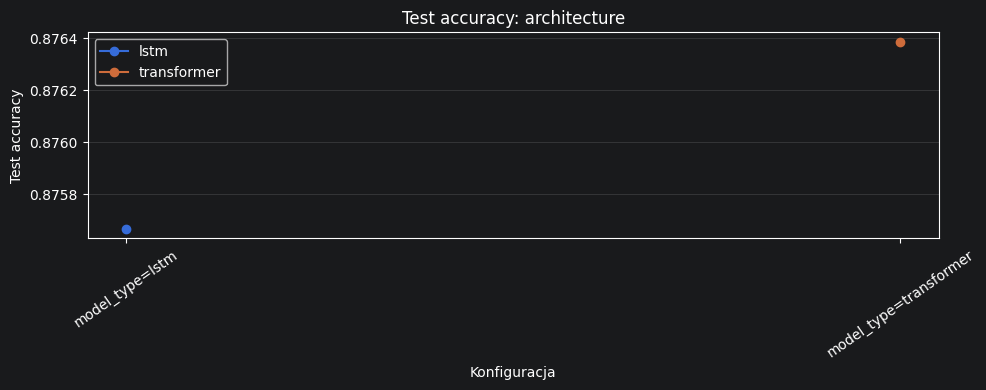

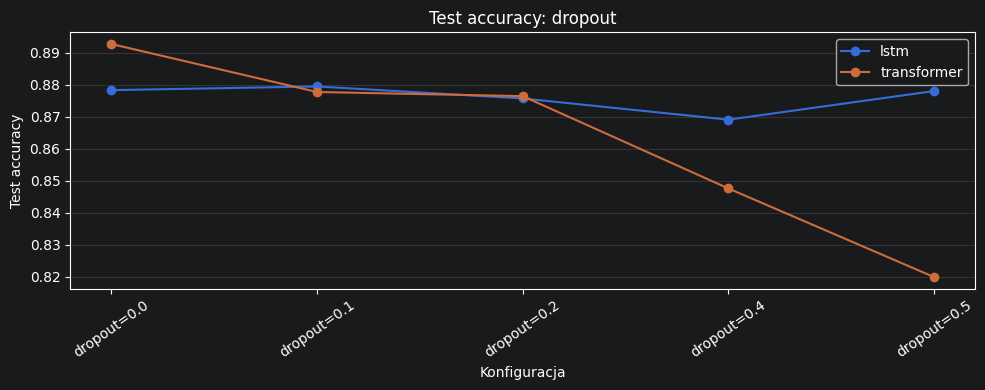

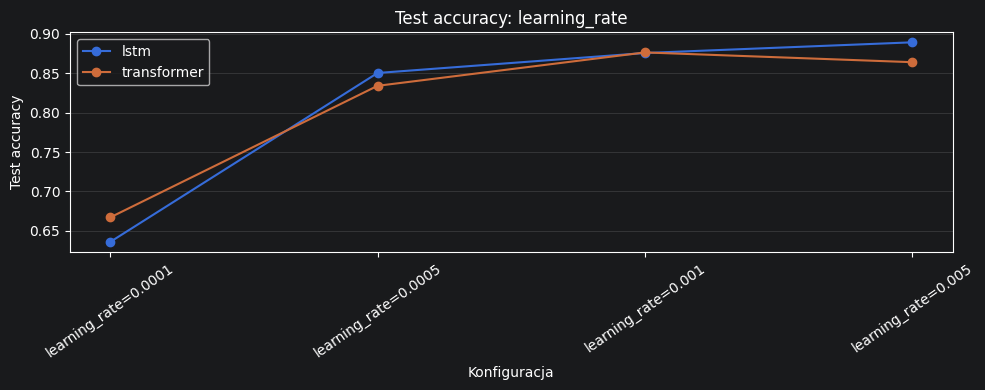

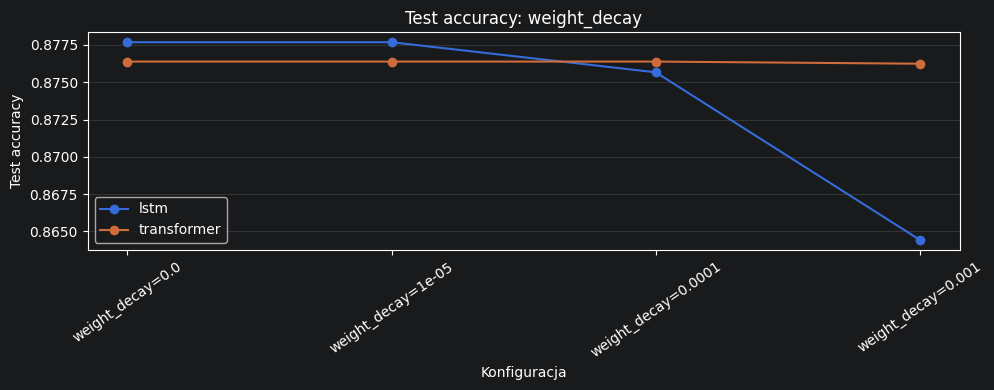

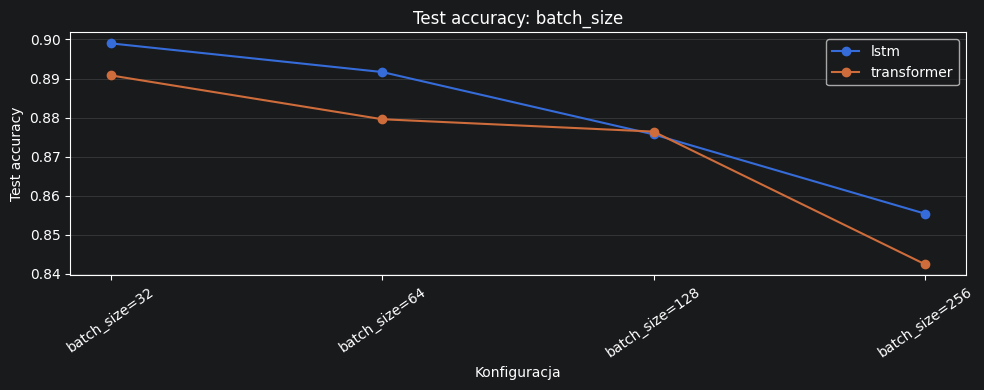

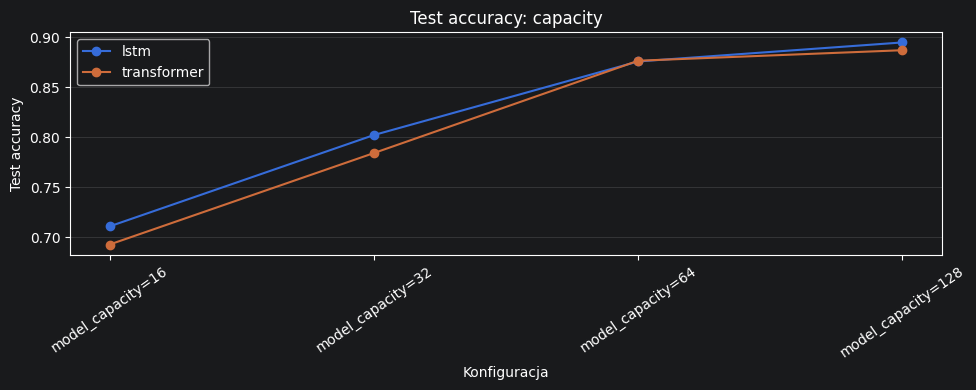

In [22]:
plot_data = all_results.copy()
plot_data["label"] = plot_data["parameter"] + "=" + plot_data["value"].astype(str)

for study, study_data in plot_data.groupby("study", sort=False):
    fig, axis = plt.subplots(figsize=(10, 4))
    for architecture, architecture_data in study_data.groupby("architecture", sort=False):
        axis.plot(
            architecture_data["label"],
            architecture_data["test_accuracy"],
            marker="o",
            label=architecture,
        )

    axis.set_title(f"Test accuracy: {study}")
    axis.set_xlabel("Konfiguracja")
    axis.set_ylabel("Test accuracy")
    axis.tick_params(axis="x", rotation=35)
    axis.legend()
    axis.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()

## Eksport wykresów porównawczych do raportu

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

summary_path = Path('reports/03_hyperparameter_experiments/hyperparameter_experiment_summary.csv')
figures_dir = Path('raport/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

results = pd.read_csv(summary_path)
results['test_accuracy_percent'] = results['test_accuracy'] * 100
results['validation_accuracy_percent'] = results['validation_accuracy'] * 100
results['value_label'] = results['value'].astype(str)

studies = ['architecture', 'dropout', 'learning_rate', 'weight_decay', 'batch_size', 'capacity']
fig, axes = plt.subplots(3, 2, figsize=(12, 12), constrained_layout=True, facecolor='white')
for ax, study in zip(axes.ravel(), studies):
    ax.set_facecolor('white')
    subset = results[results['study'] == study].copy()
    for architecture, group in subset.groupby('architecture'):
        ax.plot(
            group['value_label'],
            group['test_accuracy_percent'],
            marker='o',
            linewidth=2,
            label='LSTM' if architecture == 'lstm' else 'Transformer',
        )
    ax.set_title(study.replace('_', ' ').title())
    ax.set_xlabel('Tested value')
    ax.set_ylabel('Test accuracy [%]')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=30)
    ax.legend()
fig.suptitle('Hyperparameter experiment: test accuracy by study', fontsize=16)
fig.savefig(figures_dir / '03_hyperparameter_accuracy_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

best = (
    results.sort_values('test_accuracy', ascending=False)
    .groupby(['study', 'architecture'], as_index=False)
    .first()
)
best['architecture_label'] = best['architecture'].map({'lstm': 'LSTM', 'transformer': 'Transformer'})
best['study_label'] = best['study'].str.replace('_', ' ', regex=False).str.title()
pivot = best.pivot(index='study_label', columns='architecture_label', values='test_accuracy_percent').reindex([s.replace('_', ' ').title() for s in studies])
ax = pivot.plot(kind='bar', figsize=(10, 5), width=0.75)
figure = ax.get_figure()
figure.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.set_title('Best test accuracy per hyperparameter study')
ax.set_xlabel('Study')
ax.set_ylabel('Best test accuracy [%]')
ax.grid(axis='y', alpha=0.3)
ax.legend(title='Architecture')
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=3, fontsize=8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
figure.savefig(figures_dir / '03_best_per_study_comparison.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print(f'Saved report figures to {figures_dir.resolve()}')
